# Solution Pipeline

This notebook documents the full end-to-end pipeline for constructing a relational MLB Statcast dataset and using it to model player-season batting average. The workflow includes raw data loading, event filtering, feature engineering, aggregation to the player-season level, relational table creation, DuckDB loading, SQL queries, and predictive modeling.

In [ ]:
!pip install duckdb

In [33]:
import pandas as pd
import numpy as np
import duckdb
import os

import matplotlib.pyplot as plt
import seaborn as sns
import sys
import logging
from pathlib import Path

## Logging and error handling

The notebook uses Python logging to create a reproducible record of execution. Log messages are written both to the console and to a file in the `logs/` folder. This makes it easier to debug problems, document intermediate results, and demonstrate that the pipeline ran successfully from start to finish.


In [34]:
os.makedirs("logs", exist_ok=True)
log_path = Path("logs/statcast_pipeline.log")

for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler(log_path, mode="w", encoding="utf-8"),
        logging.StreamHandler(sys.stdout)
    ]
)

logging.info("Started DS 4320 Statcast pipeline notebook")
print(f"Logging to {log_path}")

2026-03-30 00:23:03,506 - INFO - Started DS 4320 Statcast pipeline notebook
Logging to logs/statcast_pipeline.log


## Data creation: load and combine raw Statcast files

The pipeline begins with four raw season-level Statcast CSV files covering 2018 through 2021. Only the variables needed for the project are retained in order to reduce memory usage and keep the downstream relational design focused on the refined baseball-performance question. The result of this step is one combined raw event-level table.


In [2]:
file_list = [
    "Statcast_2018.csv",
    "Statcast_2019.csv",
    "Statcast_2020.csv",
    "Statcast_2021.csv"
]

# Columns to keep
columns_to_keep = [
    "batter",
    "player_name",
    "game_year",
    "launch_speed",
    "launch_angle",
    "hit_distance_sc",
    "bb_type",
    "events",
    "estimated_woba_using_speedangle",
    "woba_value",
    "babip_value",
    "at_bat_number",
    "pitch_number"
]

# Load and combine
df_all = []

for file in file_list:
    temp = pd.read_csv(file, usecols=columns_to_keep)
    df_all.append(temp)

df = pd.concat(df_all, ignore_index=True)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (1747339, 13)


In [35]:
logging.info("Loaded raw Statcast files: %s", file_list)
logging.info("Combined raw dataframe shape: %s", df.shape)
logging.info("Columns retained: %s", list(df.columns))

2026-03-30 00:23:29,322 - INFO - Loaded raw Statcast files: ['Statcast_2018.csv', 'Statcast_2019.csv', 'Statcast_2020.csv', 'Statcast_2021.csv']
2026-03-30 00:23:29,325 - INFO - Combined raw dataframe shape: (1747339, 15)
2026-03-30 00:23:29,327 - INFO - Columns retained: ['player_name', 'batter', 'events', 'bb_type', 'game_year', 'hit_distance_sc', 'launch_speed', 'launch_angle', 'estimated_woba_using_speedangle', 'woba_value', 'babip_value', 'at_bat_number', 'pitch_number', 'is_hit', 'is_ab']


In [3]:
print("New shape:", df.shape)
print("\nColumns kept:")
print(df.columns.tolist())

display(df.head())

New shape: (1747339, 13)

Columns kept:
['player_name', 'batter', 'events', 'bb_type', 'game_year', 'hit_distance_sc', 'launch_speed', 'launch_angle', 'estimated_woba_using_speedangle', 'woba_value', 'babip_value', 'at_bat_number', 'pitch_number']


,player_name,batter,events,bb_type,game_year,hit_distance_sc,launch_speed,launch_angle,estimated_woba_using_speedangle,woba_value,babip_value,at_bat_number,pitch_number
0,"Jansen, Kenley",467827,strikeout,NaN,2018.0,NaN,NaN,NaN,NaN,0.0,0.0,71.0,4.0
1,"Jansen, Kenley",467827,NaN,NaN,2018.0,NaN,NaN,NaN,NaN,NaN,NaN,71.0,3.0
2,"Jansen, Kenley",467827,NaN,NaN,2018.0,NaN,NaN,NaN,NaN,NaN,NaN,71.0,2.0
3,"Jansen, Kenley",467827,NaN,NaN,2018.0,NaN,NaN,NaN,NaN,NaN,NaN,71.0,1.0
4,"Jansen, Kenley",435622,strikeout,NaN,2018.0,NaN,NaN,NaN,NaN,0.0,0.0,70.0,6.0


## Data processing: isolate batted-ball events

Because the goal of the project is to study how contact quality relates to batting average, the full Statcast event table is filtered to batted-ball observations. Restricting the data in this way ensures that the engineered predictors are based on balls put into play rather than on all pitch outcomes.


In [4]:
# Keep only batted ball events
df_contact = df[df["bb_type"].notna()].copy()

print("Original rows:", df.shape[0])
print("Batted ball rows:", df_contact.shape[0])

display(df_contact.head())

Original rows: 1747339
Batted ball rows: 302000


,player_name,batter,events,bb_type,game_year,hit_distance_sc,launch_speed,launch_angle,estimated_woba_using_speedangle,woba_value,babip_value,at_bat_number,pitch_number
10,"Jansen, Kenley",471865,field_out,ground_ball,2018.0,4.0,79.9,-33.0,0.081,0.0,0.0,69.0,1.0
11,"Jansen, Kenley",596115,home_run,fly_ball,2018.0,409.0,104.7,24.0,1.737,2.0,0.0,68.0,9.0
20,"Jansen, Kenley",571448,home_run,fly_ball,2018.0,414.0,107.1,23.0,1.780,2.0,0.0,67.0,1.0
21,"Johnson, DJ",571771,field_out,ground_ball,2018.0,10.0,81.0,-11.0,0.072,0.0,0.0,66.0,1.0
22,"McGee, Jake",624577,field_out,ground_ball,2018.0,8.0,65.7,-16.0,0.070,0.0,0.0,65.0,2.0


In [36]:
logging.info("Filtered to batted-ball events: original rows=%d, batted-ball rows=%d", df.shape[0], df_contact.shape[0])

2026-03-30 00:23:52,809 - INFO - Filtered to batted-ball events: original rows=1747339, batted-ball rows=302000


In [5]:
print("\nMissing launch_speed %:", df_contact["launch_speed"].isna().mean())
print("Missing launch_angle %:", df_contact["launch_angle"].isna().mean())


Missing launch_speed %: 0.014586092715231789
Missing launch_angle %: 0.014824503311258279


In [37]:
logging.info("Missing launch_speed proportion: %.6f", df_contact["launch_speed"].isna().mean())
logging.info("Missing launch_angle proportion: %.6f", df_contact["launch_angle"].isna().mean())

2026-03-30 00:24:02,534 - INFO - Missing launch_speed proportion: 0.014586
2026-03-30 00:24:02,546 - INFO - Missing launch_angle proportion: 0.014825


## Feature engineering: build player-season Statcast metrics

The batted-ball data are aggregated to the player-season level. This step converts event-level observations into interpretable baseball performance metrics such as average exit velocity, launch angle, hit distance, expected quality of contact, and batted-ball type rates. These variables form the main explanatory features used later in the model.

In [6]:
player_season_statcast = (
    df_contact
    .groupby(["batter", "game_year"])
    .agg(
        balls_in_play=("bb_type", "count"),

        avg_exit_velocity=("launch_speed", "mean"),
        avg_launch_angle=("launch_angle", "mean"),
        avg_hit_distance=("hit_distance_sc", "mean"),

        max_exit_velocity=("launch_speed", "max"),

        avg_xwoba=("estimated_woba_using_speedangle", "mean"),

        ground_ball_rate=("bb_type", lambda x: (x == "ground_ball").mean()),
        line_drive_rate=("bb_type", lambda x: (x == "line_drive").mean()),
        fly_ball_rate=("bb_type", lambda x: (x == "fly_ball").mean()),
        popup_rate=("bb_type", lambda x: (x == "popup").mean()),
    )
    .reset_index()
)

In [38]:
logging.info("Created player_season_statcast table with shape %s", player_season_statcast.shape)
logging.info("player_season_statcast columns: %s", list(player_season_statcast.columns))

2026-03-30 00:24:26,040 - INFO - Created player_season_statcast table with shape (2972, 12)
2026-03-30 00:24:26,044 - INFO - player_season_statcast columns: ['batter', 'game_year', 'balls_in_play', 'avg_exit_velocity', 'avg_launch_angle', 'avg_hit_distance', 'max_exit_velocity', 'avg_xwoba', 'ground_ball_rate', 'line_drive_rate', 'fly_ball_rate', 'popup_rate']


In [7]:
print("Shape of player-season statcast table:", player_season_statcast.shape)

display(player_season_statcast.head())

Shape of player-season statcast table: (2972, 12)


,batter,game_year,balls_in_play,avg_exit_velocity,avg_launch_angle,avg_hit_distance,max_exit_velocity,avg_xwoba,ground_ball_rate,line_drive_rate,fly_ball_rate,popup_rate
0,112526,2018.0,1,76.900000,-30.000000,4.000000,76.9,0.081000,1.000000,0.000000,0.000000,0.000000
1,134181,2018.0,345,88.697674,13.633721,187.429907,109.2,0.382826,0.391304,0.301449,0.255072,0.052174
2,282332,2019.0,1,96.800000,17.000000,297.000000,96.8,0.476000,0.000000,1.000000,0.000000,0.000000
3,400085,2018.0,37,81.311111,5.722222,125.571429,100.1,0.219333,0.567568,0.135135,0.216216,0.081081
4,400085,2019.0,4,NaN,NaN,NaN,NaN,NaN,0.500000,0.000000,0.000000,0.500000


In [8]:
print("\nSummary stats:")
print(player_season_statcast.describe())

print("\nCheck for duplicates:")
print(player_season_statcast.duplicated(subset=["batter", "game_year"]).sum())


Summary stats:
              batter    game_year  balls_in_play  avg_exit_velocity  \
count    2972.000000  2972.000000    2972.000000        2943.000000   
mean   581828.203903  2019.287349     101.615074          85.652009   
std     69201.752329     1.109702     131.292833           8.335904   
min    112526.000000  2018.000000       1.000000          20.900000   
25%    543204.500000  2018.000000      10.000000          84.160080   
50%    596104.000000  2019.000000      47.000000          87.320000   
75%    641507.000000  2020.000000     123.250000          89.775722   
max    685503.000000  2021.000000     570.000000         109.066667   

       avg_launch_angle  avg_hit_distance  max_exit_velocity    avg_xwoba  \
count       2943.000000       2930.000000        2943.000000  2943.000000   
mean           8.475148        149.955894         103.651036     0.330056   
std           15.147057         58.155925          11.674914     0.121817   
min          -77.000000          0.0

In [39]:
logging.info("Duplicate player-season keys in player_season_statcast: %d", player_season_statcast.duplicated(subset=["batter", "game_year"]).sum())

2026-03-30 00:24:39,133 - INFO - Duplicate player-season keys in player_season_statcast: 0


## Outcome construction: build player-season batting statistics

The response variable for the project is batting average. To create it, the notebook derives plate appearances, at-bats, hits, home runs, strikeouts, and walks from the event-level data and then aggregates them to the player-season level. This creates a second player-season table containing traditional batting outcomes.


In [9]:
# Create player-season batting outcomes

# First, define helper functions
def is_hit(x):
    return x in ["single", "double", "triple", "home_run"]

def is_ab(x):
    # At-bats exclude walks, hit by pitch, etc.
    return x not in ["walk", "hit_by_pitch", "sac_bunt", "sac_fly"]

# Apply flags
df["is_hit"] = df["events"].apply(lambda x: is_hit(x) if pd.notna(x) else False)
df["is_ab"] = df["events"].apply(lambda x: is_ab(x) if pd.notna(x) else False)

# Aggregate to player-season
player_season_batting = (
    df
    .groupby(["batter", "game_year"])
    .agg(
        plate_appearances=("events", "count"),
        hits=("is_hit", "sum"),
        at_bats=("is_ab", "sum"),
        home_runs=("events", lambda x: (x == "home_run").sum()),
        strikeouts=("events", lambda x: (x == "strikeout").sum()),
        walks=("events", lambda x: (x == "walk").sum()),
    )
    .reset_index()
)

# Create batting average
player_season_batting["batting_avg"] = (
    player_season_batting["hits"] / player_season_batting["at_bats"]
)

print("Shape:", player_season_batting.shape)
display(player_season_batting.head())

Shape: (3187, 9)


,batter,game_year,plate_appearances,hits,at_bats,home_runs,strikeouts,walks,batting_avg
0,112526,2018.0,4,0,4,0,3,0,0.000000
1,134181,2018.0,479,118,434,15,95,32,0.271889
2,282332,2019.0,3,0,3,0,2,0,0.000000
3,400085,2018.0,47,9,44,0,7,3,0.204545
4,400085,2019.0,6,0,5,0,1,1,0.000000


In [40]:
logging.info("Created player_season_batting table with shape %s", player_season_batting.shape)
logging.info("player_season_batting columns: %s", list(player_season_batting.columns))

2026-03-30 00:25:00,009 - INFO - Created player_season_batting table with shape (3187, 9)
2026-03-30 00:25:00,010 - INFO - player_season_batting columns: ['batter', 'game_year', 'plate_appearances', 'hits', 'at_bats', 'home_runs', 'strikeouts', 'walks', 'batting_avg']


In [10]:
print("\nCheck duplicates:")
print(player_season_batting.duplicated(subset=["batter", "game_year"]).sum())

print("\nSummary:")
print(player_season_batting.describe())


Check duplicates:
0

Summary:
              batter    game_year  plate_appearances         hits  \
count    3187.000000  3187.000000        3187.000000  3187.000000   
mean   582762.762159  2019.275808         139.593034    31.226545   
std     68877.006331     1.112132         183.778222    44.407816   
min    112526.000000  2018.000000           1.000000     0.000000   
25%    543257.000000  2018.000000          10.000000     1.000000   
50%    596129.000000  2019.000000          63.000000    12.000000   
75%    641553.000000  2020.000000         159.000000    37.000000   
max    685503.000000  2021.000000         745.000000   206.000000   

           at_bats    home_runs   strikeouts        walks  batting_avg  
count  3187.000000  3187.000000  3187.000000  3187.000000  3162.000000  
mean    125.268591     4.672419    31.618136    11.367430     0.193359  
std     164.827645     7.924788    39.769203    17.350426     0.131751  
min       0.000000     0.000000     0.000000     0.0000

In [41]:
logging.info("Duplicate player-season keys in player_season_batting: %d", player_season_batting.duplicated(subset=["batter", "game_year"]).sum())

2026-03-30 00:25:13,461 - INFO - Duplicate player-season keys in player_season_batting: 0


## Merge Statcast predictors with batting outcomes

The engineered Statcast table and the batting outcomes table are merged on the shared player-season keys. This creates a unified analytical dataset that links underlying contact-quality measures to observed batting performance.


In [11]:
# Merge predictor and outcome tables
model_df = pd.merge(
    player_season_statcast,
    player_season_batting,
    on=["batter", "game_year"],
    how="inner"
)

print("Model dataset shape:", model_df.shape)
display(model_df.head())

Model dataset shape: (2972, 19)


,batter,game_year,balls_in_play,avg_exit_velocity,avg_launch_angle,avg_hit_distance,max_exit_velocity,avg_xwoba,ground_ball_rate,line_drive_rate,fly_ball_rate,popup_rate,plate_appearances,hits,at_bats,home_runs,strikeouts,walks,batting_avg
0,112526,2018.0,1,76.900000,-30.000000,4.000000,76.9,0.081000,1.000000,0.000000,0.000000,0.000000,4,0,4,0,3,0,0.000000
1,134181,2018.0,345,88.697674,13.633721,187.429907,109.2,0.382826,0.391304,0.301449,0.255072,0.052174,479,118,434,15,95,32,0.271889
2,282332,2019.0,1,96.800000,17.000000,297.000000,96.8,0.476000,0.000000,1.000000,0.000000,0.000000,3,0,3,0,2,0,0.000000
3,400085,2018.0,37,81.311111,5.722222,125.571429,100.1,0.219333,0.567568,0.135135,0.216216,0.081081,47,9,44,0,7,3,0.204545
4,400085,2019.0,4,NaN,NaN,NaN,NaN,NaN,0.500000,0.000000,0.000000,0.500000,6,0,5,0,1,1,0.000000


In [42]:
logging.info("Merged Statcast and batting tables into model_df with shape %s", model_df.shape)

2026-03-30 00:25:34,524 - INFO - Merged Statcast and batting tables into model_df with shape (2972, 19)


In [12]:
print("\nDuplicates in model dataset:")
print(model_df.duplicated(subset=["batter", "game_year"]).sum())

print("\nMissing values by column:")
print(model_df.isna().sum())

print("\nSummary of batting_avg:")
print(model_df["batting_avg"].describe())


Duplicates in model dataset:
0

Missing values by column:
batter                0
game_year             0
balls_in_play         0
avg_exit_velocity    29
avg_launch_angle     29
avg_hit_distance     42
max_exit_velocity    29
avg_xwoba            29
ground_ball_rate      0
line_drive_rate       0
fly_ball_rate         0
popup_rate            0
plate_appearances     0
hits                  0
at_bats               0
home_runs             0
strikeouts            0
walks                 0
batting_avg          18
dtype: int64

Summary of batting_avg:
count    2954.000000
mean        0.206974
std         0.125547
min         0.000000
25%         0.153846
50%         0.225806
75%         0.266989
max         1.000000
Name: batting_avg, dtype: float64


In [43]:
logging.info("Missing values in model_df by column: %s", model_df.isna().sum().to_dict())
logging.info("Summary of batting_avg in model_df: %s", model_df["batting_avg"].describe().to_dict())

2026-03-30 00:25:45,463 - INFO - Missing values in model_df by column: {'batter': 0, 'game_year': 0, 'balls_in_play': 0, 'avg_exit_velocity': 29, 'avg_launch_angle': 29, 'avg_hit_distance': 42, 'max_exit_velocity': 29, 'avg_xwoba': 29, 'ground_ball_rate': 0, 'line_drive_rate': 0, 'fly_ball_rate': 0, 'popup_rate': 0, 'plate_appearances': 0, 'hits': 0, 'at_bats': 0, 'home_runs': 0, 'strikeouts': 0, 'walks': 0, 'batting_avg': 18}
2026-03-30 00:25:45,473 - INFO - Summary of batting_avg in model_df: {'count': 2954.0, 'mean': 0.20697411770007085, 'std': 0.12554686119212763, 'min': 0.0, '25%': 0.15384615384615385, '50%': 0.22580645161290322, '75%': 0.26698938522354204, 'max': 1.0}


## Apply qualification filters

The project focuses on player-seasons with enough opportunity to produce stable estimates. Filtering to hitters with at least 100 plate appearances and at least 50 balls in play reduces noise from very small samples and improves the reliability of the comparisons.


In [13]:
# Filter to qualified hitters
model_df_filtered = model_df[
    (model_df["plate_appearances"] >= 100) &
    (model_df["balls_in_play"] >= 50)
].copy()

print("Original model size:", model_df.shape)
print("Filtered model size:", model_df_filtered.shape)

display(model_df_filtered.head())

Original model size: (2972, 19)
Filtered model size: (1235, 19)


,batter,game_year,balls_in_play,avg_exit_velocity,avg_launch_angle,avg_hit_distance,max_exit_velocity,avg_xwoba,ground_ball_rate,line_drive_rate,fly_ball_rate,popup_rate,plate_appearances,hits,at_bats,home_runs,strikeouts,walks,batting_avg
1,134181,2018.0,345,88.697674,13.633721,187.429907,109.2,0.382826,0.391304,0.301449,0.255072,0.052174,479,118,434,15,95,32,0.271889
5,400121,2018.0,425,87.743632,13.981132,180.596354,107.6,0.333219,0.416471,0.265882,0.249412,0.068235,506,117,469,9,47,28,0.249467
6,400284,2018.0,131,87.292857,16.547619,177.906780,106.4,0.303603,0.427481,0.244275,0.274809,0.053435,185,35,164,1,34,15,0.213415
7,405395,2018.0,403,90.028288,14.148883,178.812155,112.1,0.365859,0.409429,0.263027,0.225806,0.101737,495,114,465,19,65,25,0.245161
8,405395,2019.0,431,88.294340,12.547170,166.576227,112.3,0.341953,0.461717,0.169374,0.266821,0.102088,544,120,491,23,68,42,0.244399


In [44]:
logging.info("Applied qualification filters: original model shape=%s, filtered shape=%s", model_df.shape, model_df_filtered.shape)

2026-03-30 00:26:10,270 - INFO - Applied qualification filters: original model shape=(2972, 19), filtered shape=(1235, 19)


In [14]:
print("\nNew batting_avg summary:")
print(model_df_filtered["batting_avg"].describe())


New batting_avg summary:
count    1235.000000
mean        0.251522
std         0.040045
min         0.117188
25%         0.225910
50%         0.252893
75%         0.276304
max         0.384615
Name: batting_avg, dtype: float64


## Solution analysis: linear regression for batting average prediction

This project uses a **multiple linear regression model** to predict player-season batting average using Statcast-derived measures of contact quality and batted-ball profile.

### Analysis rationale

The goal of the project is not simply to describe batting outcomes, but to test whether advanced tracking data can help explain differences in player hitting performance. A linear regression model is appropriate here because:

- the response variable, `batting_avg`, is continuous
- the predictors are interpretable baseball performance measures
- linear regression provides a clear baseline relationship between Statcast variables and batting results
- the model is easy to interpret in terms of direction and magnitude of association

The selected predictors include average and maximum exit velocity, launch angle, hit distance, expected wOBA, and batted-ball type rates. Together, these variables capture both **quality of contact** and **shape of contact**, which are central to understanding offensive production.

The train-test split is used to evaluate out-of-sample performance. This allows the project to assess whether the model generalizes beyond the specific data used to estimate the coefficients.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Select features (X) and target (y)

features = [
    "avg_exit_velocity",
    "avg_launch_angle",
    "avg_hit_distance",
    "max_exit_velocity",
    "avg_xwoba",
    "ground_ball_rate",
    "line_drive_rate",
    "fly_ball_rate",
    "popup_rate"
]

X = model_df_filtered[features]
y = model_df_filtered["batting_avg"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R^2:", r2)

MSE: 0.0012889919940585145
R^2: 0.2737395266112935


In [45]:
logging.info("Selected model features: %s", features)
logging.info("Feature matrix shape: %s; target shape: %s", X.shape, y.shape)
logging.info("Train/test split complete: X_train=%s, X_test=%s, y_train=%s, y_test=%s", X_train.shape, X_test.shape, y_train.shape, y_test.shape)
logging.info("Linear regression fitted successfully")
logging.info("Model intercept: %s", model.intercept_)
logging.info("Model coefficients: %s", dict(zip(features, model.coef_)))
logging.info("Model performance: MSE=%.6f, R2=%.6f", mse, r2)

2026-03-30 00:26:31,208 - INFO - Selected model features: ['avg_exit_velocity', 'avg_launch_angle', 'avg_hit_distance', 'max_exit_velocity', 'avg_xwoba', 'ground_ball_rate', 'line_drive_rate', 'fly_ball_rate', 'popup_rate']
2026-03-30 00:26:31,213 - INFO - Feature matrix shape: (1235, 9); target shape: (1235,)
2026-03-30 00:26:31,217 - INFO - Train/test split complete: X_train=(988, 9), X_test=(247, 9), y_train=(988,), y_test=(247,)
2026-03-30 00:26:31,220 - INFO - Linear regression fitted successfully
2026-03-30 00:26:31,224 - INFO - Model intercept: 0.23742605886155624
2026-03-30 00:26:31,227 - INFO - Model coefficients: {'avg_exit_velocity': np.float64(0.0007755902495447524), 'avg_launch_angle': np.float64(-0.0011675780190912978), 'avg_hit_distance': np.float64(-0.0005396834027640744), 'max_exit_velocity': np.float64(-0.0003561427108325596), 'avg_xwoba': np.float64(0.24168312843033313), 'ground_ball_rate': np.float64(-0.10342662356339526), 'line_drive_rate': np.float64(0.20240530874

In [16]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\nFeature Importance (Linear Coefficients):")
display(coef_df)


Feature Importance (Linear Coefficients):


,Feature,Coefficient
4,avg_xwoba,0.241683
6,line_drive_rate,0.202405
7,fly_ball_rate,0.009837
0,avg_exit_velocity,0.000776
3,max_exit_velocity,-0.000356
2,avg_hit_distance,-0.000540
1,avg_launch_angle,-0.001168
5,ground_ball_rate,-0.103427
8,popup_rate,-0.108816


In [46]:
logging.info("Coefficient table created with %d rows", coef_df.shape[0])

2026-03-30 00:26:41,872 - INFO - Coefficient table created with 9 rows


## Model interpretation

The regression coefficients show how each Statcast-derived feature is associated with batting average, holding the other included variables constant. Positive coefficients indicate that higher values of a feature are associated with higher predicted batting average, while negative coefficients indicate the opposite.

The model’s **R² of approximately 0.21** means that about 21% of the variation in batting average across filtered player-seasons is explained by the Statcast variables included in the model. In a baseball setting, this is meaningful because batting average is influenced by many factors beyond batted-ball quality alone, including defensive positioning, sprint speed, strikeout tendencies, luck on balls in play, and random variation.

The **MSE of approximately 0.0012** indicates that prediction errors are relatively small in absolute terms, though not trivial. The model captures real signal, but it is not a complete explanation of batting performance.

### Limitations

This model should be interpreted with caution. First, omitted variables may matter: for example, player speed, handedness, park effects, and defensive alignment are not included here. Second, batting average is inherently noisy and sensitive to randomness, especially on balls in play. Third, linear regression imposes a linear structure that may not fully capture more complex relationships between contact quality and outcomes.

For these reasons, the model should be viewed as a useful explanatory baseline rather than a complete representation of offensive performance.

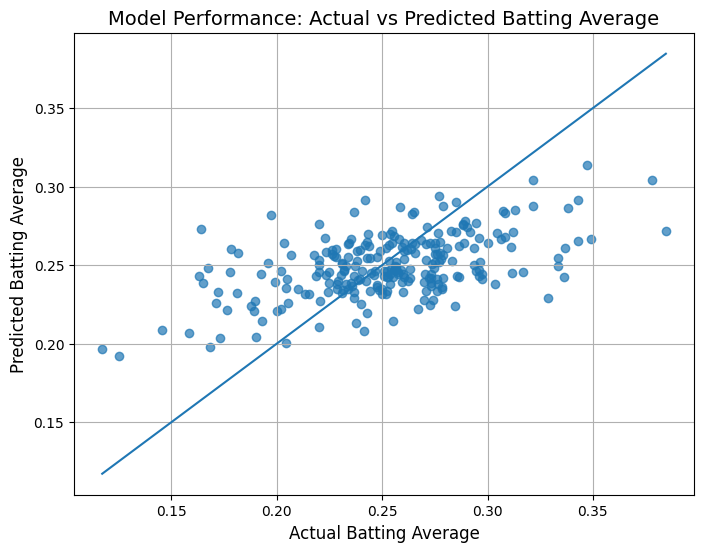

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.xlabel("Actual Batting Average", fontsize=12)
plt.ylabel("Predicted Batting Average", fontsize=12)
plt.title("Model Performance: Actual vs Predicted Batting Average", fontsize=14)

plt.grid(True)

plt.show()

In [47]:
logging.info("Generated actual-vs-predicted scatter plot for model evaluation")

2026-03-30 00:26:54,302 - INFO - Generated actual-vs-predicted scatter plot for model evaluation


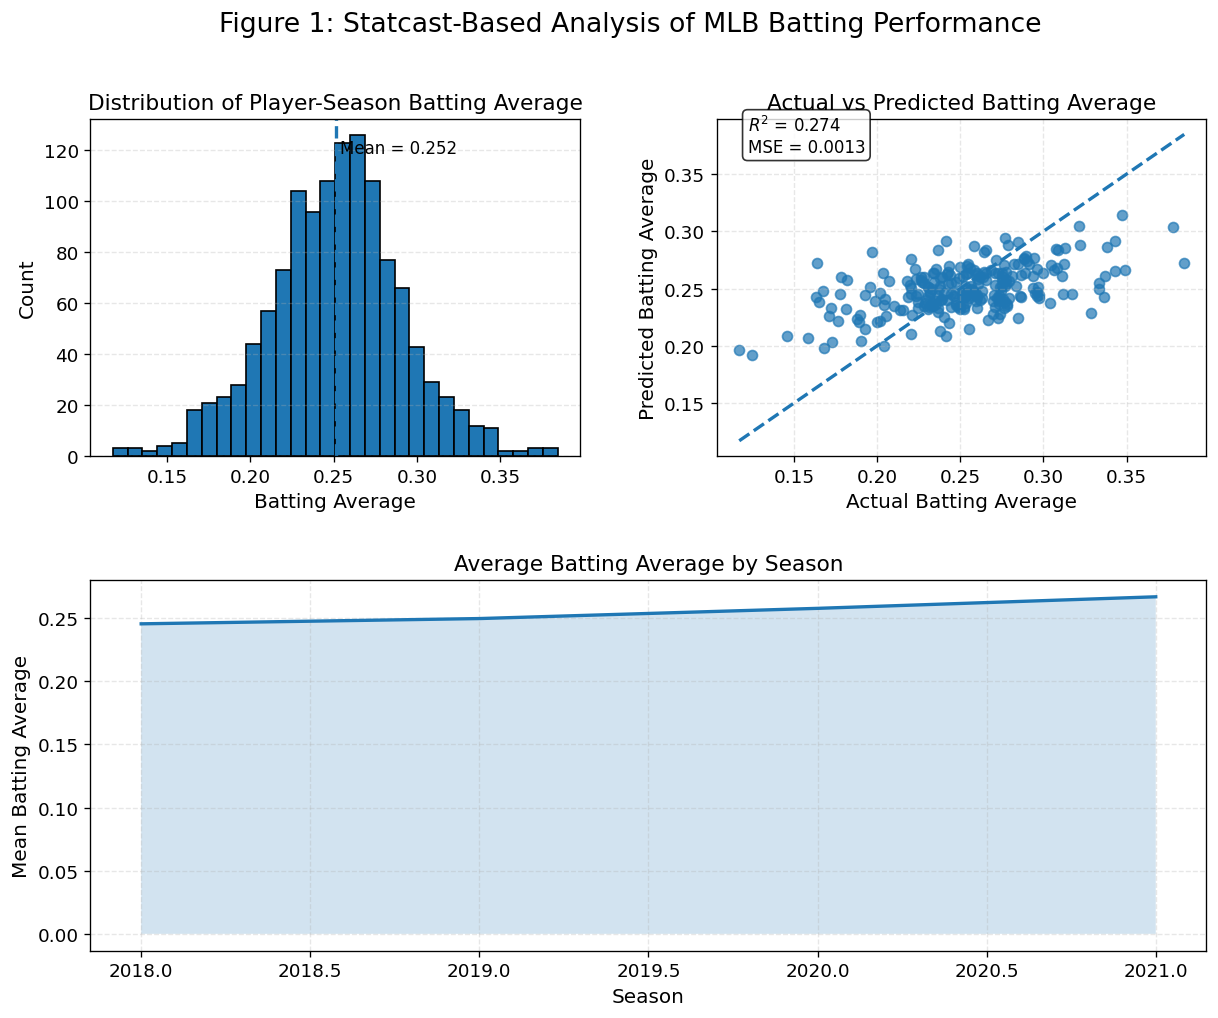

In [20]:
os.makedirs("visualizations", exist_ok=True)

# Build publication-style summary data
season_summary = (
    model_df_filtered.groupby("game_year", as_index=False)
    .agg(
        mean_batting_avg=("batting_avg", "mean"),
        n_players=("batter", "count")
    )
    .sort_values("game_year")
)

mean_ba = model_df_filtered["batting_avg"].mean()

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1], hspace=0.35, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# Top-left: batting average distribution
ax1.hist(model_df_filtered["batting_avg"], bins=30, edgecolor="black")
ax1.axvline(mean_ba, linestyle="--", linewidth=2)
ax1.set_title("Distribution of Player-Season Batting Average")
ax1.set_xlabel("Batting Average")
ax1.set_ylabel("Count")
ax1.text(
    mean_ba + 0.002,
    ax1.get_ylim()[1] * 0.9,
    f"Mean = {mean_ba:.3f}",
    fontsize=10
)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Top-right: actual vs predicted
ax2.scatter(y_test, y_pred, alpha=0.7)
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
ax2.plot([line_min, line_max], [line_min, line_max], linestyle="--", linewidth=2)
ax2.set_title("Actual vs Predicted Batting Average")
ax2.set_xlabel("Actual Batting Average")
ax2.set_ylabel("Predicted Batting Average")
ax2.text(
    line_min + 0.005,
    line_max - 0.015,
    f"$R^2$ = {r2:.3f}\nMSE = {mse:.4f}",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)
ax2.grid(True, linestyle="--", alpha=0.3)

# Bottom: batting average by season
ax3.plot(
    season_summary["game_year"],
    season_summary["mean_batting_avg"],
    linewidth=2
)
ax3.fill_between(
    season_summary["game_year"],
    season_summary["mean_batting_avg"],
    alpha=0.2
)
ax3.set_title("Average Batting Average by Season")
ax3.set_xlabel("Season")
ax3.set_ylabel("Mean Batting Average")
ax3.grid(True, linestyle="--", alpha=0.3)

fig.suptitle("Figure 1: Statcast-Based Analysis of MLB Batting Performance", fontsize=16, y=0.98)

plt.savefig("visualizations/statcast_pipeline_figure.png", bbox_inches="tight")
plt.show()

In [21]:
## Save Final Relational Tables
players = model_df_filtered[["batter"]].drop_duplicates().copy()
players["player_id"] = players["batter"]

players = players[["player_id"]]

print(players.shape)
display(players.head())

(586, 1)


,player_id
1,134181
5,400121
6,400284
7,405395
13,408045


In [48]:
logging.info("Created players dimension table with shape %s", players.shape)

2026-03-30 00:27:12,964 - INFO - Created players dimension table with shape (586, 1)


In [22]:
seasons = model_df_filtered[["game_year"]].drop_duplicates().copy()
seasons = seasons.rename(columns={"game_year": "season"})

print(seasons.shape)
display(seasons)

(4, 1)


,season
1,2018.0
8,2019.0
16,2020.0
95,2021.0


In [49]:
logging.info("Created seasons dimension table with shape %s", seasons.shape)

2026-03-30 00:27:22,172 - INFO - Created seasons dimension table with shape (4, 1)


In [23]:
player_season_statcast_final = model_df_filtered[
    [
        "batter",
        "game_year",
        "balls_in_play",
        "avg_exit_velocity",
        "avg_launch_angle",
        "avg_hit_distance",
        "max_exit_velocity",
        "avg_xwoba",
        "ground_ball_rate",
        "line_drive_rate",
        "fly_ball_rate",
        "popup_rate"
    ]
].copy()

In [50]:
logging.info("Created player_season_statcast_final table with shape %s", player_season_statcast_final.shape)

2026-03-30 00:27:32,063 - INFO - Created player_season_statcast_final table with shape (1235, 12)


In [24]:
player_season_batting_final = model_df_filtered[
    [
        "batter",
        "game_year",
        "plate_appearances",
        "hits",
        "at_bats",
        "home_runs",
        "strikeouts",
        "walks",
        "batting_avg"
    ]
].copy()

In [51]:
logging.info("Created player_season_batting_final table with shape %s", player_season_batting_final.shape)

2026-03-30 00:27:42,135 - INFO - Created player_season_batting_final table with shape (1235, 9)


In [25]:
import os

os.makedirs("data/final", exist_ok=True)

players.to_csv("data/final/players.csv", index=False)
seasons.to_csv("data/final/seasons.csv", index=False)
player_season_statcast_final.to_csv("data/final/player_season_statcast.csv", index=False)
player_season_batting_final.to_csv("data/final/player_season_batting.csv", index=False)

print("All tables saved!")

All tables saved!


In [52]:
logging.info("Saved relational CSV tables to data/final/")

2026-03-30 00:27:51,398 - INFO - Saved relational CSV tables to data/final/


## Data preparation: loading relational tables into DuckDB

To satisfy the relational-model requirement, the final cleaned dataset is stored as four related tables:

- `players`
- `seasons`
- `player_season_statcast`
- `player_season_batting`

These tables are exported as CSV files and then loaded into **DuckDB** using Python. This step demonstrates that the final dataset is not just a flat modeling table, but a relational data product that can be queried with SQL.

DuckDB is well suited to this project because it allows lightweight, local analytical SQL queries directly from Python without requiring a separate database server.

In [26]:
## Load Data into DuckDB
import duckdb

# Create connection (in-memory)
con = duckdb.connect()

print("DuckDB connected")

DuckDB connected


In [53]:
logging.info("Opened DuckDB connection")

2026-03-30 00:28:00,354 - INFO - Opened DuckDB connection


## Query: preparing and inspecting the relational solution

After loading the final tables into DuckDB, SQL queries are used to verify joins and inspect the final relational structure. The join queries demonstrate that the project’s tables connect correctly on shared keys (`batter` / `player_id` and `game_year` / `season`) and that the stored data can be used to answer baseball performance questions directly from the relational database.

These queries also show how the relational model supports downstream analysis by separating player identifiers, season identifiers, Statcast performance measures, and batting outcomes into distinct but connected tables.

In [27]:
# Load tables into DuckDB

con.execute("""
CREATE TABLE players AS
SELECT * FROM read_csv_auto('data/final/players.csv')
""")

con.execute("""
CREATE TABLE seasons AS
SELECT * FROM read_csv_auto('data/final/seasons.csv')
""")

con.execute("""
CREATE TABLE player_season_statcast AS
SELECT * FROM read_csv_auto('data/final/player_season_statcast.csv')
""")

con.execute("""
CREATE TABLE player_season_batting AS
SELECT * FROM read_csv_auto('data/final/player_season_batting.csv')
""")

print("Tables loaded into DuckDB")

Tables loaded into DuckDB


In [54]:
logging.info("Loaded all final CSV tables into DuckDB")

2026-03-30 00:28:11,738 - INFO - Loaded all final CSV tables into DuckDB


In [28]:
print(con.execute("SHOW TABLES").fetchall())

[('player_season_batting',), ('player_season_statcast',), ('players',), ('seasons',)]


In [55]:
logging.info("DuckDB tables available: %s", con.execute("SHOW TABLES").fetchall())

2026-03-30 00:28:20,395 - INFO - DuckDB tables available: []


In [29]:
query = """
SELECT
    s.batter,
    s.game_year,
    s.avg_exit_velocity,
    s.avg_launch_angle,
    s.avg_xwoba,
    b.batting_avg,
    b.home_runs
FROM player_season_statcast s
JOIN player_season_batting b
ON s.batter = b.batter
AND s.game_year = b.game_year
"""

result = con.execute(query).df()

print(result.shape)
display(result.head())

(1235, 7)


,batter,game_year,avg_exit_velocity,avg_launch_angle,avg_xwoba,batting_avg,home_runs
0,134181,2018.0,88.697674,13.633721,0.382826,0.271889,15
1,400121,2018.0,87.743632,13.981132,0.333219,0.249467,9
2,400284,2018.0,87.292857,16.547619,0.303603,0.213415,1
3,405395,2018.0,90.028288,14.148883,0.365859,0.245161,19
4,405395,2019.0,88.294340,12.547170,0.341953,0.244399,23


In [56]:
logging.info("Executed joined relational query; result shape: %s", result.shape)

2026-03-30 00:28:29,388 - INFO - Executed joined relational query; result shape: (1235, 7)


In [30]:
query_top = """
SELECT
    s.batter,
    s.game_year,
    s.avg_exit_velocity,
    b.batting_avg
FROM player_season_statcast s
JOIN player_season_batting b
ON s.batter = b.batter
AND s.game_year = b.game_year
ORDER BY s.avg_exit_velocity DESC
LIMIT 10
"""

top_players = con.execute(query_top).df()

display(top_players)

,batter,game_year,avg_exit_velocity,batting_avg
0,592450,2021.0,96.366667,0.243243
1,665489,2021.0,96.210185,0.304000
2,592450,2019.0,96.003433,0.271768
3,593934,2021.0,95.721875,0.238095
4,665487,2020.0,95.645652,0.241667
5,646240,2021.0,94.963750,0.302752
6,592885,2020.0,94.921333,0.204918
7,519317,2021.0,94.755844,0.275229
8,592450,2018.0,94.701128,0.277108
9,666971,2021.0,94.676623,0.294737


In [57]:
logging.info("Executed top exit velocity query; result shape: %s", top_players.shape)
logging.info("Completed DS 4320 Statcast pipeline notebook successfully")

2026-03-30 00:28:43,682 - INFO - Executed top exit velocity query; result shape: (10, 4)
2026-03-30 00:28:43,695 - INFO - Completed DS 4320 Statcast pipeline notebook successfully


## Query rationale

The first SQL query joins the Statcast and batting tables to reconstruct a player-season analysis view from the relational tables. This demonstrates that the stored tables preserve the information needed for modeling and interpretation.

The second query identifies player-seasons with the highest average exit velocity, which is a useful example of how the relational database can answer substantive baseball questions beyond the regression itself. These examples show that the final data product is both analytically useful and consistent with relational design principles.

In [32]:
import duckdb
import os

con = duckdb.connect()
data_folder = "."

for file in os.listdir(data_folder):
    if file.startswith("Statcast") and file.endswith(".csv"):
        csv_path = os.path.join(data_folder, file)
        parquet_path = os.path.join(data_folder, file.replace(".csv", ".parquet"))

        con.execute(f"""
        COPY (
            SELECT *
            FROM read_csv_auto(
                '{csv_path}',
                strict_mode = false,
                null_padding = true,
                ignore_errors = true,
                sample_size = -1
            )
        )
        TO '{parquet_path}' (FORMAT PARQUET);
        """)

        print(f"Converted {file} -> {parquet_path}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Converted Statcast_2019.csv -> ./Statcast_2019.parquet
Converted Statcast_2021.csv -> ./Statcast_2021.parquet
Converted Statcast_2020.csv -> ./Statcast_2020.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Converted Statcast_2018.csv -> ./Statcast_2018.parquet


## How this pipeline solves the problem

This end-to-end workflow matches the refined project goal: **use MLB Statcast data to explain and predict player batting average at the player-season level**.

- **Raw Statcast event data** from 2018–2021 are combined into a unified dataset covering millions of tracked observations.
- The pipeline filters to **batted-ball events**, which focuses the analysis on contact quality rather than all pitch outcomes.
- These event-level observations are aggregated into **player-season Statcast features**, including average exit velocity, launch angle, hit distance, expected wOBA, and batted-ball type rates.
- The same raw data are also used to construct **player-season batting outcomes**, including plate appearances, at-bats, hits, and batting average.
- These two player-season tables are merged to create a final modeling dataset linking **underlying contact characteristics** to **observed batting performance**.
- The filtered final dataset is stored as a **four-table relational database**, satisfying the project’s relational-model requirement.
- **DuckDB** is then used to load and query those tables, showing that the final data product is not only suitable for modeling, but also usable as a structured analytical database.
- A **linear regression model** is fit to predict batting average from Statcast-derived variables.
- The visualization shows that the model captures meaningful signal while also revealing the remaining unexplained variation in batting outcomes.

### What the results show

The model achieves an **R² of about 0.21** and an **MSE of about 0.0012**, indicating that Statcast contact-quality variables explain a meaningful portion of player-season batting average, even though batting performance remains partly driven by omitted variables and randomness.

### Why this solves the problem

The original problem was to move beyond traditional batting statistics and test whether deeper tracking data could improve understanding of player performance. This pipeline solves that problem by transforming raw Statcast observations into a relational analytical dataset, using that dataset to estimate a predictive model, and showing that advanced contact metrics provide measurable explanatory power for batting average.